In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data=pd.read_csv("EV_Bikes_India.csv")

In [4]:
data.head()

,Model,Battery Capacity (kWh),Acceleration (sec),Top Speed (km/h),Range (km),Max Power (kW),Max Torque (Nm),Price (INR),Products Sold Till Today
0,Ather 450X,2.90,3.3,80,146,6.00,26,109000,38359
1,Revolt RV400,3.24,3.0,85,150,3.00,54,125000,13969
2,Okinawa i-Praise+,3.30,4.0,75,139,2.50,40,146000,19527
3,Bajaj Chetak,3.00,4.5,70,95,4.08,16,122000,9997
4,TVS iQube,2.25,4.2,78,75,4.40,140,161000,25483


In [5]:
data.shape

(210, 9)

In [6]:
data.describe()

,Battery Capacity (kWh),Acceleration (sec),Top Speed (km/h),Range (km),Max Power (kW),Max Torque (Nm),Price (INR),Products Sold Till Today
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,2.100000e+02,210.000000
mean,4.422333,4.120000,95.566667,159.166667,8.160000,64.733333,2.147493e+05,24282.547619
std,2.005619,1.522708,26.614883,53.397721,7.047133,30.145030,2.576718e+05,14616.859842
min,1.500000,2.600000,25.000000,75.000000,0.250000,16.000000,6.150000e+04,1124.000000
25%,3.000000,3.100000,80.000000,121.000000,4.400000,54.000000,1.100000e+05,10032.750000
50%,4.000000,3.950000,92.500000,150.000000,6.000000,60.000000,1.525000e+05,25021.000000
75%,4.800000,4.500000,120.000000,200.000000,9.000000,72.000000,1.980000e+05,37697.500000
max,10.300000,10.000000,155.000000,323.000000,31.000000,165.000000,1.525000e+06,49788.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Model                     210 non-null    object 
 1   Battery Capacity (kWh)    210 non-null    float64
 2   Acceleration (sec)        210 non-null    float64
 3   Top Speed (km/h)          210 non-null    int64  
 4   Range (km)                210 non-null    int64  
 5   Max Power (kW)            210 non-null    float64
 6   Max Torque (Nm)           210 non-null    int64  
 7   Price (INR)               210 non-null    int64  
 8   Products Sold Till Today  210 non-null    int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 14.9+ KB


In [8]:
data.isnull().sum()

Model                       0
Battery Capacity (kWh)      0
Acceleration (sec)          0
Top Speed (km/h)            0
Range (km)                  0
Max Power (kW)              0
Max Torque (Nm)             0
Price (INR)                 0
Products Sold Till Today    0
dtype: int64

In [9]:
features = data[["Battery Capacity (kWh)", "Range (km)", "Max Power (kW)", "Price (INR)", "Top Speed (km/h)"]]

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Determine the optimal number of clusters using the Elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

In [10]:
inertia

[1049.9999999999998,
 564.5951664241434,
 423.3877688952891,
 261.88263984163854,
 196.9194191968155,
 161.3704232234669,
 133.46331884085618,
 123.28840572251467,
 100.87954585475475,
 76.03806295645933]

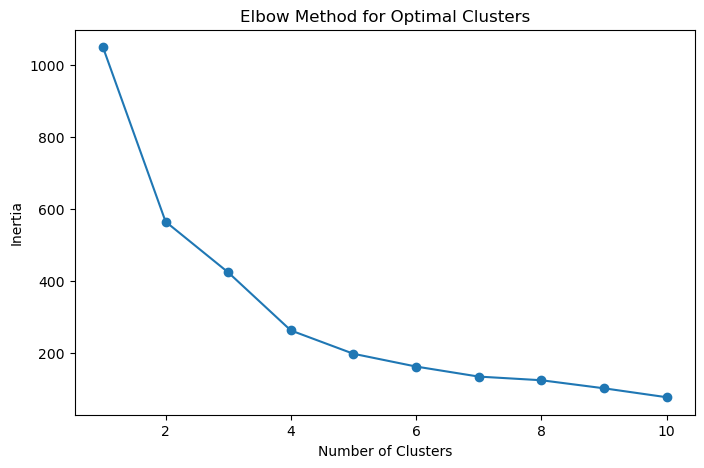

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


In [12]:
optimal_k = 4  # Replace this with the number of clusters from the elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(features_scaled)

# Analyze clusters
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                               columns=features.columns)
cluster_centers['Cluster'] = range(optimal_k)

In [13]:
data.to_csv('Clustered_Electric_Bikes.csv', index=False)

# Print cluster centers
cluster_centers

,Battery Capacity (kWh),Range (km),Max Power (kW),Price (INR),Top Speed (km/h),Cluster
0,3.273333,120.666667,4.953333,154498.6,78.866667,0
1,9.650000,261.500000,25.000000,329500.0,145.000000,1
2,8.900000,130.000000,31.000000,1525000.0,120.000000,2
3,4.614167,192.666667,7.458333,161750.0,106.166667,3


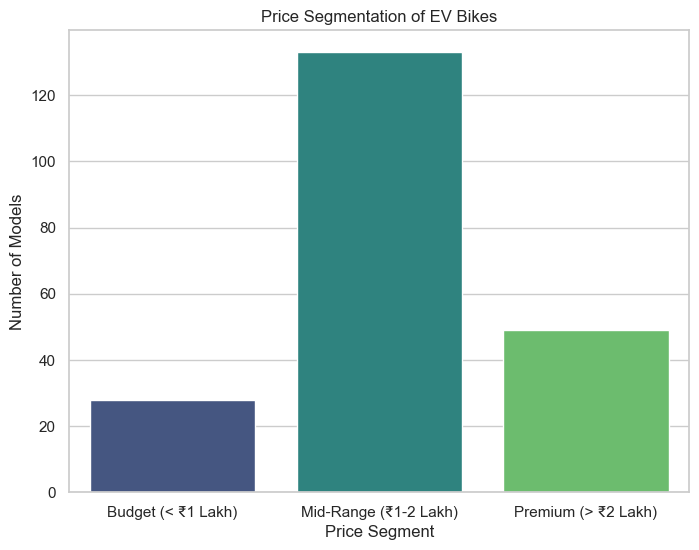

In [15]:
sns.set(style="whitegrid")

# 1. Price Segmentation
price_segments = {
    "Budget (< ₹1 Lakh)": len(data[data["Price (INR)"] < 100000]),
    "Mid-Range (₹1-2 Lakh)": len(data[(data["Price (INR)"] >= 100000) & (data["Price (INR)"] <= 200000)]),
    "Premium (> ₹2 Lakh)": len(data[data["Price (INR)"] > 200000]),
}

plt.figure(figsize=(8, 6))
sns.barplot(x=list(price_segments.keys()), y=list(price_segments.values()), palette="viridis")
plt.title('Price Segmentation of EV Bikes')
plt.ylabel('Number of Models')
plt.xlabel('Price Segment')
plt.show()

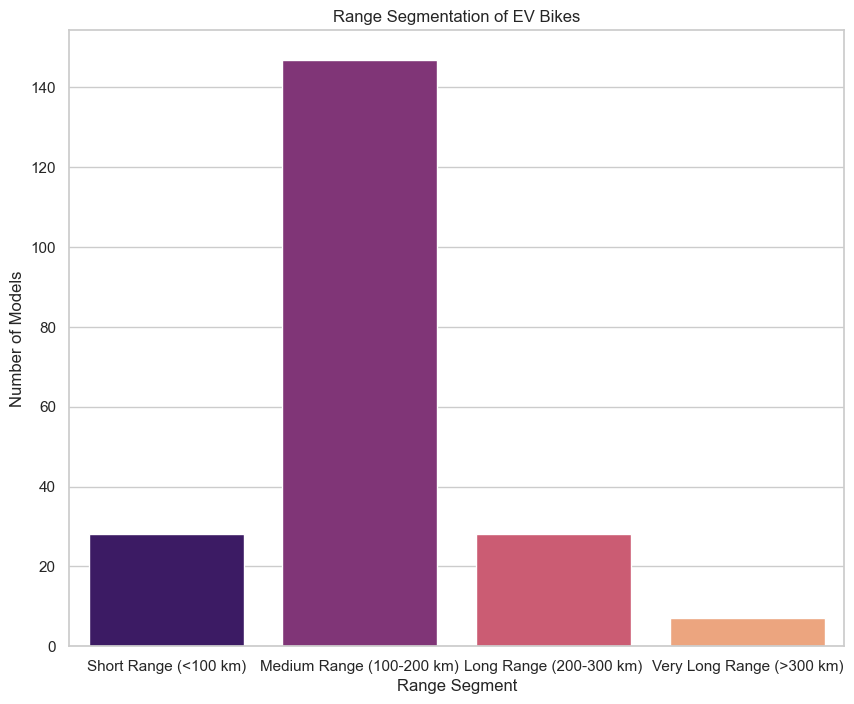

In [20]:
# 2. Range Segmentation
range_bins = [0, 100, 200, 300, 400]
range_labels = ["Short Range (<100 km)", "Medium Range (100-200 km)", "Long Range (200-300 km)", "Very Long Range (>300 km)"]

data['Range Segment'] = pd.cut(data['Range (km)'], bins=range_bins, labels=range_labels)

plt.figure(figsize=(10,8))
sns.countplot(data, x='Range Segment', palette="magma")
plt.title('Range Segmentation of EV Bikes')
plt.ylabel('Number of Models')
plt.xlabel('Range Segment')
plt.show()



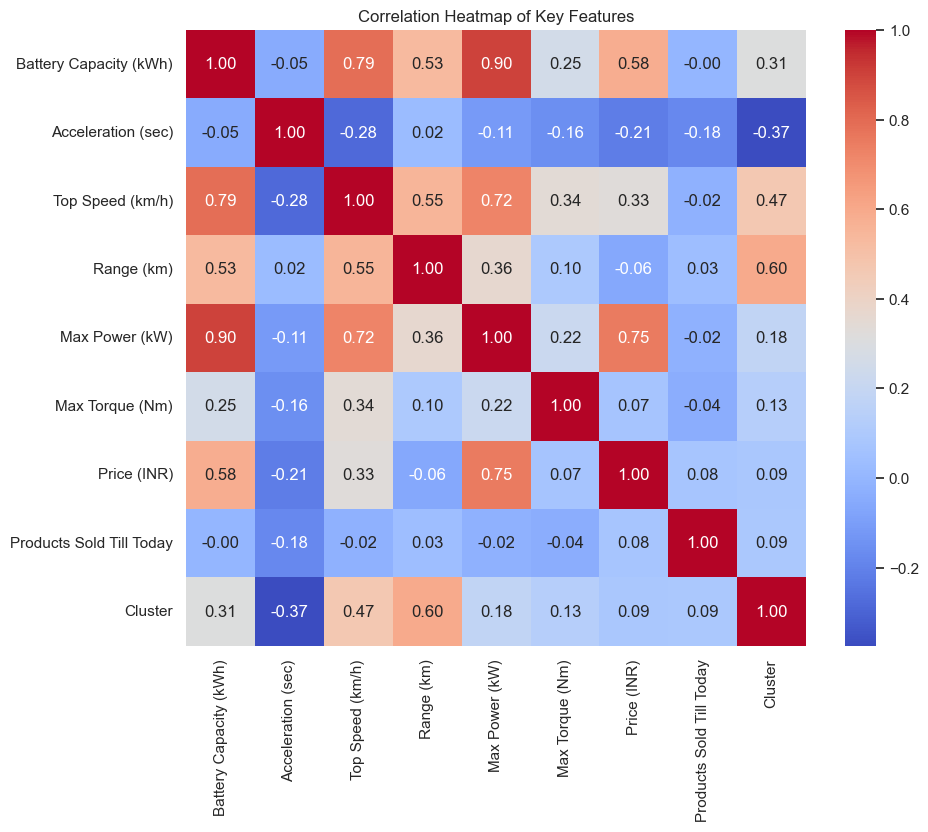

In [23]:
# Filter only numeric columns
numeric_data = data.select_dtypes(include='number')

# Generate the correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = numeric_data.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap of Key Features')
plt.show()


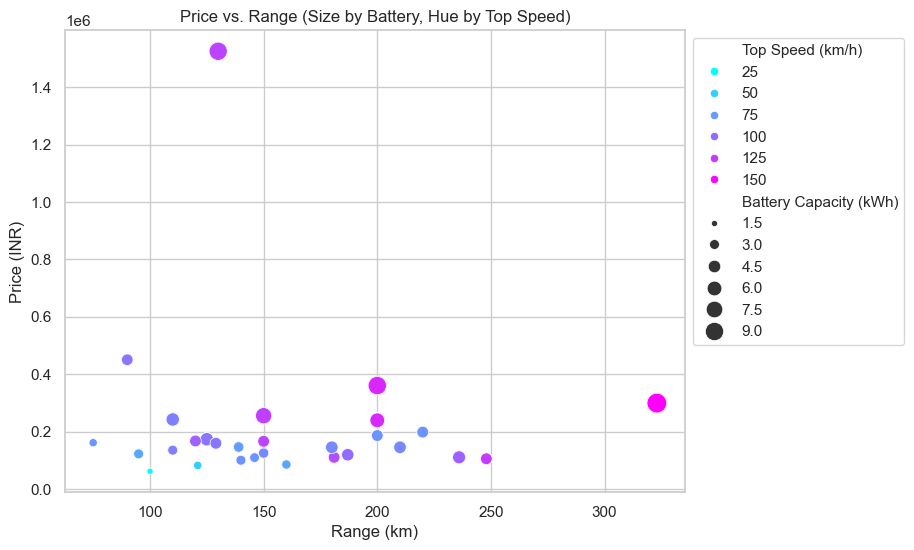

In [24]:
# 4. Price vs. Range
plt.figure(figsize=(8, 6))
sns.scatterplot(data, x='Range (km)', y='Price (INR)', hue='Top Speed (km/h)', size='Battery Capacity (kWh)', 
                sizes=(20, 200), palette="cool", legend="brief")
plt.title('Price vs. Range (Size by Battery, Hue by Top Speed)')
plt.xlabel('Range (km)')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

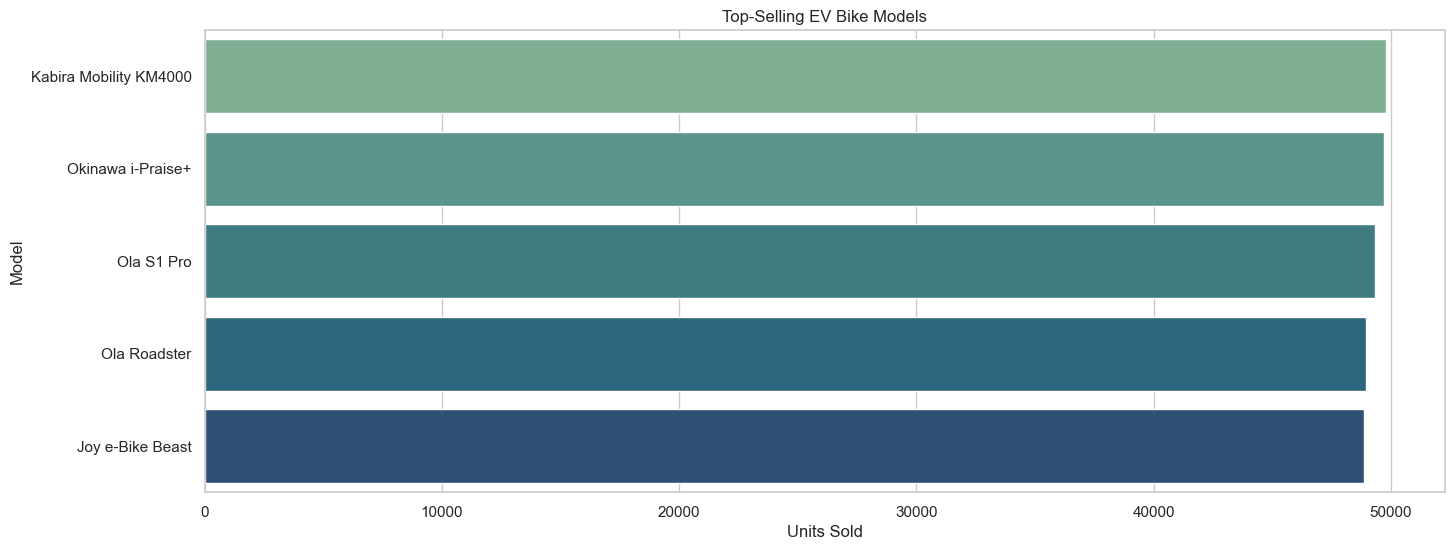

In [31]:
# 5. Top-Selling Models
top_selling = data.nlargest(5, 'Products Sold Till Today')[['Model', 'Products Sold Till Today']]

plt.figure(figsize=(16, 6))
sns.barplot(data=top_selling, x='Products Sold Till Today', y='Model', palette="crest")
plt.title('Top-Selling EV Bike Models')
plt.xlabel('Units Sold')
plt.ylabel('Model')
plt.show()

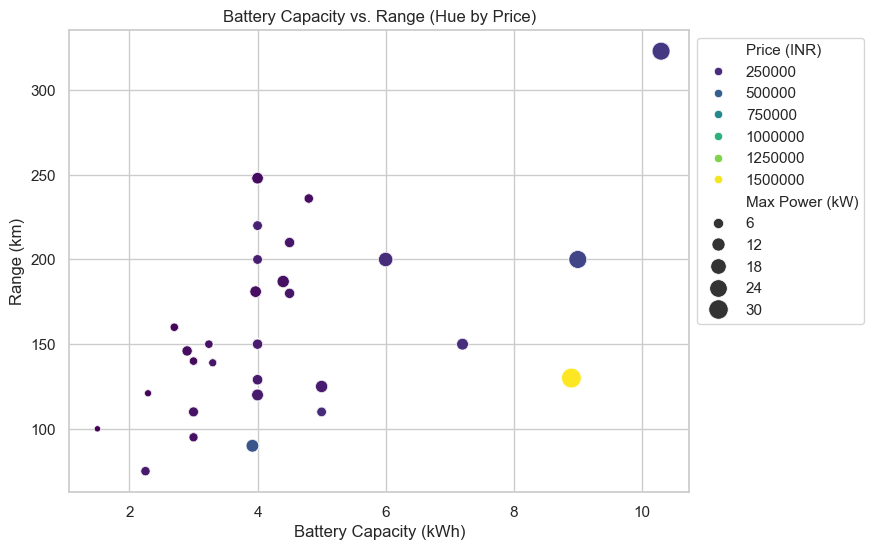

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data, x='Battery Capacity (kWh)', y='Range (km)', hue='Price (INR)', 
                size='Max Power (kW)', sizes=(20, 200), palette="viridis")
plt.title('Battery Capacity vs. Range (Hue by Price)')
plt.xlabel('Battery Capacity (kWh)')
plt.ylabel('Range (km)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()